# Adapter :: T2I-Adapter

-----
- Conda env : [cv_playgrounds](../../README.md#setup-a-conda-environment)
-----

- Ref: 
    - https://huggingface.co/docs/diffusers/v0.34.0/en/using-diffusers/t2i_adapter

## 0. Configure device

In [5]:
#@title
import torch

if torch.backends.mps.is_available():
    t_device = torch.device("mps")
    s_device = "mps"
    print(f"Current memory allocated on MPS: {torch.mps.current_allocated_memory()} bytes")
    print(f"Driver memory allocated on MPS: {torch.mps.driver_allocated_memory()} bytes")
    if torch.mps.driver_allocated_memory() - torch.mps.current_allocated_memory()< 1e4:
        print("Not enough mps memory, convert to cpu mode")
        t_device = torch.device("cpu")
        s_device = "cpu"
elif torch.cuda.is_available():
    t_device = torch.device("cuda")
    s_device = "cuda"
else:
    t_device = torch.device("cpu")
    s_device = "cpu"
print(t_device)

cuda


In [6]:
import torch
from diffusers import T2IAdapter, StableDiffusionXLAdapterPipeline, AutoencoderKL

t2i_adapter = T2IAdapter.from_pretrained(
    "TencentARC/t2i-adapter-canny-sdxl-1.0",
    torch_dtype=torch.float16,
)

In [7]:
import cv2
import numpy as np
from PIL import Image
from diffusers.utils import load_image

original_image = load_image(
    "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/non-enhanced-prompt.png"
)

image = np.array(original_image)

low_threshold = 100
high_threshold = 200

image = cv2.Canny(image, low_threshold, high_threshold)
image = image[:, :, None]
image = np.concatenate([image, image, image], axis=2)
canny_image = Image.fromarray(image)

In [8]:
vae = AutoencoderKL.from_pretrained("madebyollin/sdxl-vae-fp16-fix", torch_dtype=torch.float16)
pipeline = StableDiffusionXLAdapterPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    adapter=t2i_adapter,
    vae=vae,
    torch_dtype=torch.float16,
).to(t_device)

prompt = """
A photorealistic overhead image of a cat reclining sideways in a flamingo pool floatie holding a margarita. 
The cat is floating leisurely in the pool and completely relaxed and happy.
"""

out = pipeline(
    prompt, 
    image=canny_image,
    num_inference_steps=100, 
    guidance_scale=10,
).images[0]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

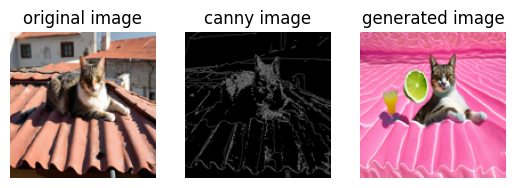

In [21]:
import matplotlib.pyplot as plt

plt.subplot(1, 3, 1) 
plt.imshow(original_image.resize((128, 128)))
plt.title("original image")
plt.axis('off')
plt.subplot(1, 3, 2) 
plt.imshow(canny_image.resize((128, 128)))
plt.title("canny image")
plt.axis('off')
plt.subplot(1, 3, 3) 
plt.imshow(out.resize((128, 128)))
plt.title("generated image")
plt.axis('off')
plt.show()


In [22]:
del pipeline

import torch

import gc
gc.collect()
torch.cuda.empty_cache()

### MultiAdapter

In [23]:
import torch
from diffusers.utils import load_image
from diffusers import StableDiffusionXLAdapterPipeline, AutoencoderKL, MultiAdapter, T2IAdapter

canny_image = load_image(
    "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/canny-cat.png"
)
depth_image = load_image(
    "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/sdxl_depth_image.png"
)
controls = [canny_image, depth_image]
prompt = ["""
a relaxed rabbit sitting on a striped towel next to a pool with a tropical drink nearby, 
bright sunny day, vacation scene, 35mm photograph, film, professional, 4k, highly detailed
"""]

adapters = MultiAdapter(
    [
        T2IAdapter.from_pretrained("TencentARC/t2i-adapter-canny-sdxl-1.0", torch_dtype=torch.float16),
        T2IAdapter.from_pretrained("TencentARC/t2i-adapter-depth-midas-sdxl-1.0", torch_dtype=torch.float16),
    ]
)

diffusion_pytorch_model.safetensors:   0%|          | 0.00/316M [00:00<?, ?B/s]

In [24]:
vae = AutoencoderKL.from_pretrained("madebyollin/sdxl-vae-fp16-fix", torch_dtype=torch.float16)
pipeline = StableDiffusionXLAdapterPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16,
    vae=vae,
    adapter=adapters,
).to(t_device)

out = pipeline(
    prompt,
    image=controls,
    height=1024,
    width=1024,
    adapter_conditioning_scale=[0.7, 0.7]
).images[0]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

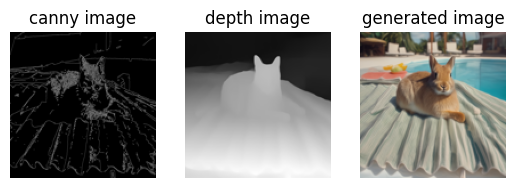

In [25]:
import matplotlib.pyplot as plt

plt.subplot(1, 3, 1) 
plt.imshow(canny_image.resize((128, 128)))
plt.title("canny image")
plt.axis('off')
plt.subplot(1, 3, 2) 
plt.imshow(depth_image.resize((128, 128)))
plt.title("depth image")
plt.axis('off')
plt.subplot(1, 3, 3) 
plt.imshow(out.resize((128, 128)))
plt.title("generated image")
plt.axis('off')
plt.show()